In [1]:
import os
import re
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import joblib

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.ensemble import (
    IsolationForest,
    RandomForestClassifier,
    ExtraTreesClassifier,
    RandomForestRegressor,
    HistGradientBoostingClassifier,
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



In [19]:
ROOT = Path("tcm_modelling")
DATA_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs"

for p in [DATA_DIR, PROCESSED_DIR, MODEL_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

MAIN_DATASET_ID = 3      # dataset 3 has all 4 anomaly types and no drift
DRIFT_DATASET_ID = 5     # dataset 5 has all 4 anomaly types and drift
ZENODO_RECORD_ID = "11469702"


OBS_PER_SHIFT = 200

RUN_AUTOENCODER_BASELINE = True 

In [7]:
def clean_col(c: str) -> str:
    c = str(c).strip()
    c = c.replace(" ", "_").replace("-", "_")
    c = re.sub(r"[^A-Za-z0-9_]+", "", c)
    c = re.sub(r"_+", "_", c)
    return c.lower().strip("_")

In [4]:
raw_df = pd.read_csv(f"./tcm_dataset/11469702/tcm5_dataset_{MAIN_DATASET_ID}.csv")

In [8]:
raw_df.columns = [clean_col(c) for c in raw_df.columns]
raw_df["timestamp_index"] = np.arange(len(raw_df))
raw_df

,thickness_entry,thickness_exit,width,ys_entry,ys_exit,work_roll_diam_1,work_roll_diam_2,work_roll_diam_3,work_roll_diam_4,work_roll_diam_5,work_roll_mileage_1,work_roll_mileage_2,work_roll_mileage_3,work_roll_mileage_4,work_roll_mileage_5,reduction_1,reduction_2,reduction_3,reduction_4,reduction_5,tension_0,tension_1,tension_2,tension_3,tension_4,tension_5,roll_speed_1,roll_speed_2,roll_speed_3,roll_speed_4,roll_speed_5,force_1,force_2,force_3,force_4,force_5,torque_1,torque_2,torque_3,torque_4,torque_5,gap_1,gap_2,gap_3,gap_4,gap_5,motor_power_1,motor_power_2,motor_power_3,motor_power_4,motor_power_5,anomaly_reduction,anomaly_electric_1,anomaly_bearing_1,anomaly_workroll_1,anomaly_electric_2,anomaly_bearing_2,anomaly_workroll_2,anomaly_electric_3,anomaly_bearing_3,anomaly_workroll_3,anomaly_electric_4,anomaly_bearing_4,anomaly_workroll_4,anomaly_electric_5,anomaly_bearing_5,anomaly_workroll_5,timestamp_index
0,3.7,1.31,1002.0,372.0,566.0,557.0,549.0,562.0,594.0,581.0,0.00,0.00,0.00,0.00,0.00,0.3359,0.2518,0.1642,0.0970,0.0559,77651.0,145583.0,170887.0,196943.0,219356.0,74302.0,7.954,10.631,12.719,14.086,14.920,9952103.0,8129896.0,6537499.0,4894698.0,3722926.0,129786.0,98371.0,81829.0,59903.0,56053.0,2.237,1.665,1.393,1.285,1.224,3823.261410,3889.868179,3818.271180,2931.606299,2954.259351,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
1,2.6,0.74,1237.0,273.0,492.0,557.0,549.0,562.0,594.0,581.0,1.02,1.37,1.64,1.81,1.92,0.3704,0.3001,0.1986,0.1291,0.0746,40837.0,75941.0,88019.0,100078.0,111961.0,35628.0,6.470,9.243,11.534,13.245,14.312,9069928.0,7653329.0,6551690.0,5409851.0,3769775.0,94126.0,82754.0,73347.0,59391.0,54336.0,1.495,0.953,0.782,0.624,0.652,2284.145807,2963.677823,3207.114375,2785.603920,2790.038028,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1
2,2.6,0.67,1000.0,273.0,501.0,557.0,549.0,562.0,594.0,581.0,2.42,3.36,4.12,4.66,5.00,0.3923,0.3101,0.2231,0.1389,0.0813,32679.0,57906.0,66062.0,73271.0,84798.0,26751.0,6.579,9.536,12.274,14.254,15.514,7775951.0,6503166.0,6050099.0,5092652.0,3580068.0,86216.0,76616.0,66935.0,58439.0,49505.0,1.415,0.917,0.699,0.612,0.581,2135.045382,2832.954880,3079.938544,3017.926041,2813.271900,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2
3,3.9,1.43,1132.0,273.0,467.0,557.0,549.0,562.0,594.0,581.0,4.10,5.80,7.27,8.32,8.98,0.3309,0.2281,0.1719,0.0956,0.0520,68046.0,131426.0,155684.0,181702.0,198441.0,67357.0,5.715,7.404,8.941,9.887,10.429,8568009.0,6544408.0,5851157.0,4252818.0,3171771.0,97663.0,71092.0,80441.0,59174.0,52653.0,2.423,1.837,1.521,1.366,1.326,2148.282472,2017.586893,2705.571593,2078.499630,2010.812794,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,3
4,3.9,1.43,1132.0,273.0,467.0,557.0,549.0,562.0,594.0,581.0,4.98,6.94,8.64,9.84,10.58,0.3250,0.2425,0.1612,0.0976,0.0525,68992.0,134467.0,155711.0,175489.0,198207.0,60779.0,7.180,9.479,11.300,12.522,13.217,8332592.0,6685709.0,5674187.0,4370277.0,3034196.0,95089.0,75011.0,75823.0,60694.0,54461.0,2.467,1.867,1.573,1.376,1.340,2594.291383,2708.079883,3272.765166,2697.708062,2614.435051,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19998,3.9,1.43,1132.0,273.0,467.0,542.0,541.0,567.0,577.0,589.0,38.29,98.84,53.48,52.62,19.49,0.3381,0.2278,0.1667,0.0930,0.0508,66481.0,134782.0,156690.0,175236.0,199310.0,69294.0,6.837,8.854,10.626,11.716,12.342,8623010.0,6309508.0,5841099.0,4159642.0,3121495.0,103332.0,66961.0,77216.0,59667.0,53832.0,2.424,1.811,1.563,1.417,1.361,2782.712845,2351.401647,2956.831946,2581.172960,2348.96

In [9]:
drift_raw_df = pd.read_csv(f"./tcm_dataset/11469702/tcm5_dataset_{DRIFT_DATASET_ID}.csv")
drift_raw_df.columns = [clean_col(c) for c in drift_raw_df.columns]
drift_raw_df["timestamp_index"] = np.arange(len(drift_raw_df))
drift_raw_df

,thickness_entry,thickness_exit,width,ys_entry,ys_exit,work_roll_diam_1,work_roll_diam_2,work_roll_diam_3,work_roll_diam_4,work_roll_diam_5,work_roll_mileage_1,work_roll_mileage_2,work_roll_mileage_3,work_roll_mileage_4,work_roll_mileage_5,reduction_1,reduction_2,reduction_3,reduction_4,reduction_5,tension_0,tension_1,tension_2,tension_3,tension_4,tension_5,roll_speed_1,roll_speed_2,roll_speed_3,roll_speed_4,roll_speed_5,force_1,force_2,force_3,force_4,force_5,torque_1,torque_2,torque_3,torque_4,torque_5,gap_1,gap_2,gap_3,gap_4,gap_5,motor_power_1,motor_power_2,motor_power_3,motor_power_4,motor_power_5,anomaly_reduction,anomaly_electric_1,anomaly_bearing_1,anomaly_workroll_1,anomaly_electric_2,anomaly_bearing_2,anomaly_workroll_2,anomaly_electric_3,anomaly_bearing_3,anomaly_workroll_3,anomaly_electric_4,anomaly_bearing_4,anomaly_workroll_4,anomaly_electric_5,anomaly_bearing_5,anomaly_workroll_5,timestamp_index
0,3.2,1.19,1160.0,325.0,535.0,549.0,547.0,570.0,581.0,570.0,0.00,0.00,0.00,0.00,0.00,0.3236,0.2399,0.1608,0.0931,0.0495,70458.0,133856.0,157775.0,177070.0,201070.0,66403.0,8.451,11.119,13.249,14.610,15.370,9582470.0,7576354.0,6557669.0,4879850.0,3464667.0,98733.0,74746.0,78645.0,59314.0,54269.0,1.936,1.502,1.288,1.142,1.046,3137.825274,3130.002240,3775.090255,3087.554263,3000.975462,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
1,3.2,1.19,1160.0,325.0,535.0,549.0,547.0,570.0,581.0,570.0,1.10,1.45,1.72,1.90,2.00,0.3247,0.2277,0.1693,0.0954,0.0511,66330.0,133452.0,152841.0,181984.0,201857.0,67241.0,4.349,5.631,6.778,7.493,7.897,9640532.0,7466028.0,6783704.0,4936622.0,3571407.0,101128.0,72410.0,82457.0,59087.0,51848.0,1.949,1.533,1.250,1.055,1.108,1704.677536,1570.695827,2057.286397,1621.123794,1522.543902,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1
2,2.5,0.73,1060.0,440.0,690.0,549.0,547.0,570.0,581.0,570.0,2.20,2.87,3.44,3.80,4.00,0.3655,0.2851,0.2136,0.1170,0.0731,51075.0,99028.0,122157.0,137019.0,149688.0,50598.0,4.810,6.728,8.555,9.688,10.453,12181178.0,10209218.0,9603831.0,7424106.0,5623378.0,129890.0,105227.0,96766.0,62610.0,58018.0,1.309,0.946,0.694,0.615,0.602,2335.683672,2727.842110,3050.784410,2219.521458,2267.319346,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2
3,2.5,0.73,1060.0,440.0,690.0,549.0,547.0,570.0,581.0,570.0,3.75,5.04,6.20,6.92,7.37,0.3672,0.2786,0.2153,0.1236,0.0698,57459.0,102338.0,121143.0,139315.0,153942.0,52937.0,6.210,8.608,10.970,12.517,13.457,12092019.0,10061520.0,9536666.0,7542506.0,5629447.0,133467.0,105299.0,97587.0,61317.0,56877.0,1.324,0.931,0.709,0.560,0.596,3220.706391,3528.465446,3924.020692,2756.090891,2833.141761,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,3
4,3.2,1.19,1160.0,325.0,535.0,549.0,547.0,570.0,581.0,570.0,5.31,7.20,8.94,10.05,10.74,0.3251,0.2363,0.1604,0.0933,0.0523,65387.0,129913.0,156321.0,177417.0,203552.0,65847.0,7.302,9.561,11.388,12.561,13.253,9516980.0,7545955.0,6520067.0,4737998.0,3540707.0,102059.0,73212.0,76316.0,56601.0,54260.0,1.990,1.483,1.204,1.141,1.137,2753.371750,2723.850392,3198.426237,2597.761424,2680.416924,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20000,4.0,1.69,1233.0,325.0,521.0,551.0,539.0,560.0,583.0,585.0,114.05,50.52,11.08,114.14,43.50,0.2988,0.2117,0.1320,0.0805,0.0423,102503.0,198052.0,240872.0,272357.0,302395.0,98871.0,6.128,7.773,8.956,9.740,10.170,10206465.0,7838039.0,6394668.0,4715578.0,3574645.0,113891.0,75073.0,82392.0,62320.0,55469.0,2.579,2.052,1.792,1.708,1.541,2706.067337,2337.147053,2750.849581,2166.

In [10]:
anomaly_cols = [c for c in raw_df.columns if c.startswith("anomaly")]
feature_cols_raw = [c for c in raw_df.columns if c not in anomaly_cols]

print("Anomaly columns:", len(anomaly_cols))
print(anomaly_cols)
print("Raw feature columns:", len(feature_cols_raw))


for c in anomaly_cols:
    raw_df[c] = pd.to_numeric(raw_df[c], errors="coerce").fillna(0).astype(int)
    if c in drift_raw_df.columns:
        drift_raw_df[c] = pd.to_numeric(drift_raw_df[c], errors="coerce").fillna(0).astype(int)

raw_df["is_anomaly"] = (raw_df[anomaly_cols].sum(axis=1) > 0).astype(int)
drift_raw_df["is_anomaly"] = (drift_raw_df[[c for c in anomaly_cols if c in drift_raw_df.columns]].sum(axis=1) > 0).astype(int)

summary = pd.DataFrame({
    "metric": ["rows", "columns", "anomaly_columns", "anomaly_rows", "anomaly_rate"],
    "main_dataset": [len(raw_df), raw_df.shape[1], len(anomaly_cols), int(raw_df["is_anomaly"].sum()), raw_df["is_anomaly"].mean()],
    "drift_dataset": [len(drift_raw_df), drift_raw_df.shape[1], len([c for c in anomaly_cols if c in drift_raw_df.columns]), int(drift_raw_df["is_anomaly"].sum()), drift_raw_df["is_anomaly"].mean()],
})
display(summary)

display(raw_df[anomaly_cols].sum().sort_values(ascending=False).to_frame("positive_count"))

Anomaly columns: 16
['anomaly_reduction', 'anomaly_electric_1', 'anomaly_bearing_1', 'anomaly_workroll_1', 'anomaly_electric_2', 'anomaly_bearing_2', 'anomaly_workroll_2', 'anomaly_electric_3', 'anomaly_bearing_3', 'anomaly_workroll_3', 'anomaly_electric_4', 'anomaly_bearing_4', 'anomaly_workroll_4', 'anomaly_electric_5', 'anomaly_bearing_5', 'anomaly_workroll_5']
Raw feature columns: 52


,metric,main_dataset,drift_dataset
0,rows,20003.000000,20005.000000
1,columns,69.000000,69.000000
2,anomaly_columns,16.000000,16.000000
3,anomaly_rows,981.000000,1031.000000
4,anomaly_rate,0.049043,0.051537


,positive_count
anomaly_reduction,239
anomaly_electric_4,76
anomaly_workroll_3,70
anomaly_electric_2,70
anomaly_workroll_4,70
anomaly_electric_5,70
anomaly_electric_1,61
anomaly_bearing_3,61
anomaly_workroll_1,56
anomaly_workroll_5,56


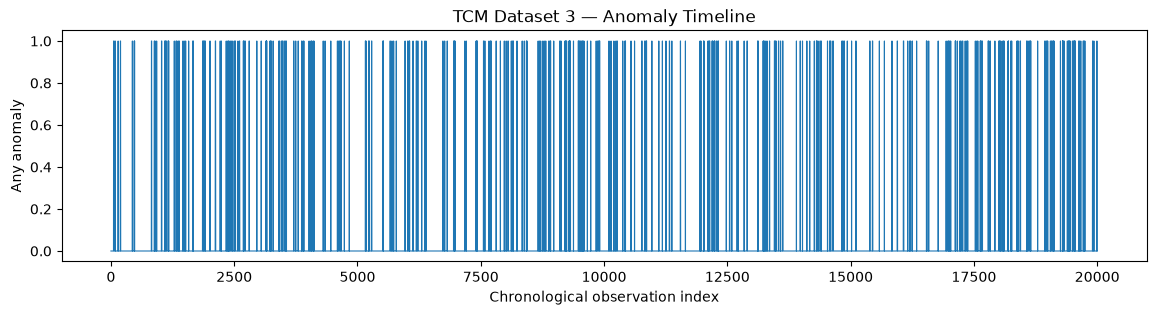

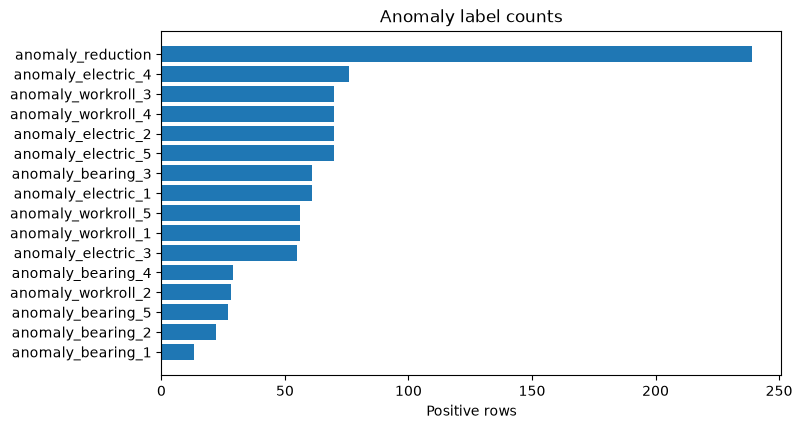

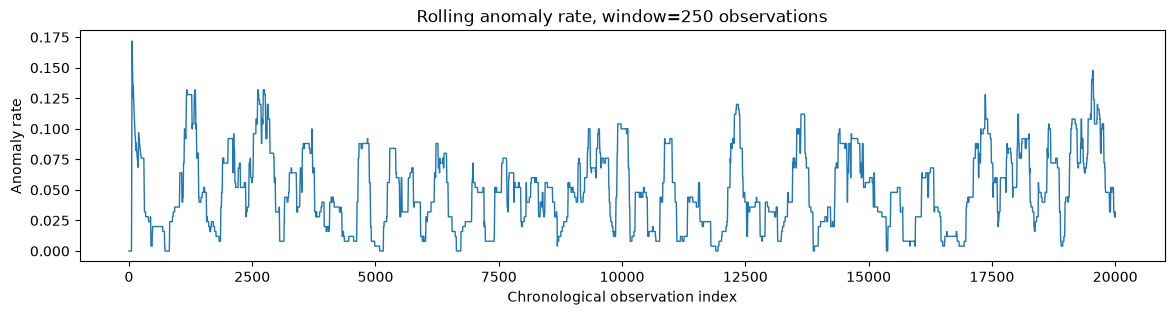

In [11]:
plt.figure(figsize=(14, 3))
plt.plot(raw_df["timestamp_index"], raw_df["is_anomaly"], linewidth=0.8)
plt.title("TCM Dataset 3 — Anomaly Timeline")
plt.xlabel("Chronological observation index")
plt.ylabel("Any anomaly")
plt.show()

label_counts = raw_df[anomaly_cols].sum().sort_values(ascending=True)
plt.figure(figsize=(8, max(4, len(label_counts) * 0.28)))
plt.barh(label_counts.index, label_counts.values)
plt.title("Anomaly label counts")
plt.xlabel("Positive rows")
plt.show()


rolling_rate = raw_df["is_anomaly"].rolling(250, min_periods=1).mean()
plt.figure(figsize=(14, 3))
plt.plot(raw_df["timestamp_index"], rolling_rate, linewidth=1)
plt.title("Rolling anomaly rate, window=250 observations")
plt.xlabel("Chronological observation index")
plt.ylabel("Anomaly rate")
plt.show()

In [12]:
def active_faults_for_row(row, cols):
    return [c for c in cols if int(row.get(c, 0)) == 1]


def dominant_fault_for_row(row, cols):
    active = active_faults_for_row(row, cols)
    if not active:
        return "normal"
    priority_order = ["bearing", "electric", "workroll", "reduction"]
    for key in priority_order:
        for c in active:
            if key in c:
                return c
    return active[0]

raw_df["active_faults"] = raw_df.apply(lambda r: ",".join(active_faults_for_row(r, anomaly_cols)), axis=1)
raw_df["dominant_fault"] = raw_df.apply(lambda r: dominant_fault_for_row(r, anomaly_cols), axis=1)

display(raw_df["dominant_fault"].value_counts().to_frame("count"))

,count
dominant_fault,
normal,19022
anomaly_reduction,229
anomaly_electric_4,73
anomaly_electric_5,70
anomaly_electric_2,70
anomaly_workroll_3,67
anomaly_workroll_4,64
anomaly_electric_1,61
anomaly_bearing_3,61


In [13]:
def safe_div(a, b, eps=1e-9):
    return a / (b.replace(0, np.nan) + eps)


def add_if_exists(df, new_col, func, required_cols):
    if all(c in df.columns for c in required_cols):
        df[new_col] = func(df)
    return df


def feature_engineer_tcm(df_in: pd.DataFrame, windows=(10, 30, 60)) -> pd.DataFrame:
    df = df_in.copy()

    protected = set(["active_faults", "dominant_fault"])
    for c in df.columns:
        if c not in protected:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    for i in range(1, 6):
        torque = f"torque_{i}"
        force = f"force_{i}"
        power = f"motor_power_{i}"
        reduction = f"reduction_{i}"
        speed = f"roll_speed_{i}"
        mileage = f"work_roll_mileage_{i}"

        add_if_exists(df, f"torque_to_force_ratio_{i}", lambda x, t=torque, f=force: safe_div(x[t], x[f]), [torque, force])
        add_if_exists(df, f"power_to_torque_ratio_{i}", lambda x, p=power, t=torque: safe_div(x[p], x[t]), [power, torque])
        add_if_exists(df, f"force_per_reduction_{i}", lambda x, f=force, r=reduction: safe_div(x[f], x[r]), [force, reduction])
        add_if_exists(df, f"motor_load_index_{i}", lambda x, p=power, t=torque: x[p] * x[t], [power, torque])
        add_if_exists(df, f"speed_power_ratio_{i}", lambda x, s=speed, p=power: safe_div(x[s], x[p]), [speed, power])

        if mileage in df.columns:
            mn, mx = df[mileage].min(), df[mileage].max()
            df[f"mileage_norm_{i}"] = (df[mileage] - mn) / (mx - mn + 1e-9)

    for base in ["torque", "force", "motor_power", "roll_speed", "gap", "reduction"]:
        for i in range(2, 6):
            c1, c0 = f"{base}_{i}", f"{base}_{i-1}"
            if c1 in df.columns and c0 in df.columns:
                df[f"{base}_diff_{i}_{i-1}"] = df[c1] - df[c0]
                df[f"{base}_ratio_{i}_{i-1}"] = safe_div(df[c1], df[c0])

    key_prefixes = ["torque", "force", "motor_power", "gap", "reduction", "roll_speed"]
    key_cols = []
    for pref in key_prefixes:
        key_cols += [f"{pref}_{i}" for i in range(1, 6) if f"{pref}_{i}" in df.columns]
    key_cols += [f"tension_{i}" for i in range(0, 6) if f"tension_{i}" in df.columns]

    for col in key_cols:
        df[f"{col}_delta_1"] = df[col].diff()
        for w in windows:
            roll = df[col].rolling(w, min_periods=max(3, w // 3))
            mean_col = f"{col}_roll_mean_{w}"
            std_col = f"{col}_roll_std_{w}"
            df[mean_col] = roll.mean()
            df[std_col] = roll.std()
            df[f"{col}_ewm_{w}"] = df[col].ewm(span=w, adjust=False).mean()
            df[f"{col}_z_recent_{w}"] = (df[col] - df[mean_col]) / (df[std_col] + 1e-9)
            df[f"{col}_slope_{w}"] = (df[col] - df[col].shift(w)) / max(w, 1)

    
    df = df.replace([np.inf, -np.inf], np.nan)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].ffill().bfill().fillna(0)
    return df

feat_df = feature_engineer_tcm(raw_df)
drift_feat_df = feature_engineer_tcm(drift_raw_df)

print("Raw shape:", raw_df.shape)
print("Feature engineered shape:", feat_df.shape)
display(feat_df.head())

Raw shape: (20003, 71)
Feature engineered shape: (20003, 725)


,thickness_entry,thickness_exit,width,ys_entry,ys_exit,work_roll_diam_1,work_roll_diam_2,work_roll_diam_3,work_roll_diam_4,work_roll_diam_5,work_roll_mileage_1,work_roll_mileage_2,work_roll_mileage_3,work_roll_mileage_4,work_roll_mileage_5,reduction_1,reduction_2,reduction_3,reduction_4,reduction_5,tension_0,tension_1,tension_2,tension_3,tension_4,tension_5,roll_speed_1,roll_speed_2,roll_speed_3,roll_speed_4,roll_speed_5,force_1,force_2,force_3,force_4,force_5,torque_1,torque_2,torque_3,torque_4,torque_5,gap_1,gap_2,gap_3,gap_4,gap_5,motor_power_1,motor_power_2,motor_power_3,motor_power_4,motor_power_5,anomaly_reduction,anomaly_electric_1,anomaly_bearing_1,anomaly_workroll_1,anomaly_electric_2,anomaly_bearing_2,anomaly_workroll_2,anomaly_electric_3,anomaly_bearing_3,anomaly_workroll_3,anomaly_electric_4,anomaly_bearing_4,anomaly_workroll_4,anomaly_electric_5,anomaly_bearing_5,anomaly_workroll_5,timestamp_index,is_anomaly,active_faults,dominant_fault,torque_to_force_ratio_1,power_to_torque_ratio_1,force_per_reduction_1,motor_load_index_1,...,tension_1_slope_10,tension_1_roll_mean_30,tension_1_roll_std_30,tension_1_ewm_30,tension_1_z_recent_30,tension_1_slope_30,tension_1_roll_mean_60,tension_1_roll_std_60,tension_1_ewm_60,tension_1_z_recent_60,tension_1_slope_60,tension_2_delta_1,tension_2_roll_mean_10,tension_2_roll_std_10,tension_2_ewm_10,tension_2_z_recent_10,tension_2_slope_10,tension_2_roll_mean_30,tension_2_roll_std_30,tension_2_ewm_30,tension_2_z_recent_30,tension_2_slope_30,tension_2_roll_mean_60,tension_2_roll_std_60,tension_2_ewm_60,tension_2_z_recent_60,tension_2_slope_60,tension_3_delta_1,tension_3_roll_mean_10,tension_3_roll_std_10,tension_3_ewm_10,tension_3_z_recent_10,tension_3_slope_10,tension_3_roll_mean_30,tension_3_roll_std_30,tension_3_ewm_30,tension_3_z_recent_30,tension_3_slope_30,tension_3_roll_mean_60,tension_3_roll_std_60,tension_3_ewm_60,tension_3_z_recent_60,tension_3_slope_60,tension_4_delta_1,tension_4_roll_mean_10,tension_4_roll_std_10,tension_4_ewm_10,tension_4_z_recent_10,tension_4_slope_10,tension_4_roll_mean_30,tension_4_roll_std_30,tension_4_ewm_30,tension_4_z_recent_30,tension_4_slope_30,tension_4_roll_mean_60,tension_4_roll_std_60,tension_4_ewm_60,tension_4_z_recent_60,tension_4_slope_60,tension_5_delta_1,tension_5_roll_mean_10,tension_5_roll_std_10,tension_5_ewm_10,tension_5_z_recent_10,tension_5_slope_10,tension_5_roll_mean_30,tension_5_roll_std_30,tension_5_ewm_30,tension_5_z_recent_30,tension_5_slope_30,tension_5_roll_mean_60,tension_5_roll_std_60,tension_5_ewm_60,tension_5_z_recent_60,tension_5_slope_60
0,3.7,1.31,1002.0,372.0,566.0,557.0,549.0,562.0,594.0,581.0,0.00,0.00,0.00,0.00,0.00,0.3359,0.2518,0.1642,0.0970,0.0559,77651.0,145583.0,170887.0,196943.0,219356.0,74302.0,7.954,10.631,12.719,14.086,14.920,9952103.0,8129896.0,6537499.0,4894698.0,3722926.0,129786.0,98371.0,81829.0,59903.0,56053.0,2.237,1.665,1.393,1.285,1.224,3823.261410,3889.868179,3818.271180,2931.606299,2954.259351,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,,normal,0.013041,0.029458,2.962817e+07,4.962058e+08,...,-1633.6,121382.2,29305.462857,145583.000000,0.351805,-2292.233333,103541.9,38797.282635,145583.000000,-1.236476,-1194.033333,-82868.0,108322.666667,55283.354785,170887.000000,-0.764437,-1537.1,140932.9,34462.319321,170887.000000,0.367216,-2916.633333,120484.7,45157.801583,170887.000000,-1.246046,-1384.966667,-96865.0,123430.666667,65059.212847,196943.000000,-0.770985,-2106.9,160568.7,40018.857658,196943.000000,0.400968,-3242.866667,137843.8,50621.193913,196943.000000,-1.242618,-1613.3,-107395.0,138705.0,71154.023028,219356.000000,-0.757610,-1797.4,180439.1,44218.277497,219356.000000,0.358424,-3494.9,154946.6,57877.458718,219356.000000,-1.276328,-1802.666667,-38674.0,45560.333333,25283.647568,74302.000000,-0.743933,-1169.9,58684.2,15067.677951,74302.000000,0.312311,-1217.233333,50909.3,19298.612688,74302.000000,-1.376073,-582.766667
1,2.6,0.74,1237.0,273.0,492.0,557.0,549.0,562.0,594.0,581.0,1.02,1.37,1.64,1.81,1.92,0.

In [14]:
def add_proxy_rul_targets(df_in: pd.DataFrame, obs_per_shift: int = OBS_PER_SHIFT) -> pd.DataFrame:
    df = df_in.copy()
    y = df["is_anomaly"].astype(int).values
    n = len(df)
    next_idx = np.full(n, np.nan)
    next_seen = np.nan

    for i in range(n - 1, -1, -1):
        if y[i] == 1:
            next_seen = i
        next_idx[i] = next_seen

    rul_obs = next_idx - np.arange(n)
    max_cap = obs_per_shift * 10
    rul_obs = np.where(np.isnan(rul_obs), max_cap, rul_obs)
    rul_obs = np.clip(rul_obs, 0, max_cap)

    df["proxy_rul_obs"] = rul_obs.astype(float)
    df["proxy_rul_shifts"] = df["proxy_rul_obs"] / float(obs_per_shift)

    def band_from_obs(v):
        if v <= 0:
            return "immediate"
        if v <= obs_per_shift:
            return "within_1_shift"
        if v <= 3 * obs_per_shift:
            return "within_3_shifts"
        if v <= 7 * obs_per_shift:
            return "within_7_shifts"
        return "monitor"

    df["rul_urgency_band"] = df["proxy_rul_obs"].apply(band_from_obs)
    band_order = {
        "immediate": 4,
        "within_1_shift": 3,
        "within_3_shifts": 2,
        "within_7_shifts": 1,
        "monitor": 0,
    }
    df["rul_urgency_id"] = df["rul_urgency_band"].map(band_order).astype(int)
    return df

feat_df = add_proxy_rul_targets(feat_df)
drift_feat_df = add_proxy_rul_targets(drift_feat_df)

display(feat_df[["timestamp_index", "is_anomaly", "dominant_fault", "proxy_rul_obs", "proxy_rul_shifts", "rul_urgency_band", "rul_urgency_id"]].head(15))
display(feat_df["rul_urgency_band"].value_counts().to_frame("count"))

,timestamp_index,is_anomaly,dominant_fault,proxy_rul_obs,proxy_rul_shifts,rul_urgency_band,rul_urgency_id
0,0,0,normal,53.0,0.265,within_1_shift,3
1,1,0,normal,52.0,0.260,within_1_shift,3
2,2,0,normal,51.0,0.255,within_1_shift,3
3,3,0,normal,50.0,0.250,within_1_shift,3
4,4,0,normal,49.0,0.245,within_1_shift,3
5,5,0,normal,48.0,0.240,within_1_shift,3
6,6,0,normal,47.0,0.235,within_1_shift,3
7,7,0,normal,46.0,0.230,within_1_shift,3
8,8,0,normal,45.0,0.225,within_1_shift,3
9,9,0,normal,44.0,0.220,within_1_shift,3


,count
rul_urgency_band,
within_1_shift,18268
immediate,981
within_3_shifts,746
monitor,8


In [15]:
exclude_cols = set(anomaly_cols + [
    "is_anomaly",
    "active_faults",
    "dominant_fault",
    "proxy_rul_obs",
    "proxy_rul_shifts",
    "rul_urgency_band",
    "rul_urgency_id",
])

all_numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in all_numeric_cols if c not in exclude_cols]

common_feature_cols = [c for c in feature_cols if c in drift_feat_df.columns]
feature_cols = common_feature_cols

n = len(feat_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_idx = np.arange(0, train_end)
val_idx = np.arange(train_end, val_end)
test_idx = np.arange(val_end, n)

X_train = feat_df.loc[train_idx, feature_cols]
X_val = feat_df.loc[val_idx, feature_cols]
X_test = feat_df.loc[test_idx, feature_cols]

y_train = feat_df.loc[train_idx, "is_anomaly"].astype(int)
y_val = feat_df.loc[val_idx, "is_anomaly"].astype(int)
y_test = feat_df.loc[test_idx, "is_anomaly"].astype(int)

print("Features:", len(feature_cols))
print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
print("Anomaly rate train/val/test:", y_train.mean(), y_val.mean(), y_test.mean())

Features: 706
Train/Val/Test: (14002, 706) (3000, 706) (3001, 706)
Anomaly rate train/val/test: 0.04642193972289673 0.04133333333333333 0.06897700766411197


In [16]:
def evaluate_binary_scores(y_true, scores, threshold=0.5, title="Model"):
    y_pred = (scores >= threshold).astype(int)
    out = {
        "model": title,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan,
    }
    print("\n", title)
    print(json.dumps(out, indent=2))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, zero_division=0))
    return out


def tune_threshold(y_true, scores, objective="f1", min_recall=None):
    thresholds = np.linspace(0.01, 0.99, 99)
    best = None
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if min_recall is not None and rec < min_recall:
            continue
        score = f1 if objective == "f1" else prec
        row = {"threshold": float(t), "precision": prec, "recall": rec, "f1": f1, "score": score}
        if best is None or row["score"] > best["score"]:
            best = row
    return best or {"threshold": 0.5, "precision": 0, "recall": 0, "f1": 0, "score": 0}


def plot_pr_curve(y_true, scores, title):
    p, r, _ = precision_recall_curve(y_true, scores)
    plt.figure(figsize=(6, 4))
    plt.plot(r, p)
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True, alpha=0.3)
    plt.show()


 IsolationForest baseline
{
  "model": "IsolationForest baseline",
  "threshold": 0.41000000000000003,
  "precision": 0.1343692870201097,
  "recall": 0.7101449275362319,
  "f1": 0.22598001537279017,
  "accuracy": 0.6644451849383539,
  "roc_auc": 0.7393534800244832,
  "pr_auc": 0.16492775749575755
}
Confusion matrix:
[[1847  947]
 [  60  147]]
              precision    recall  f1-score   support

           0       0.97      0.66      0.79      2794
           1       0.13      0.71      0.23       207

    accuracy                           0.66      3001
   macro avg       0.55      0.69      0.51      3001
weighted avg       0.91      0.66      0.75      3001



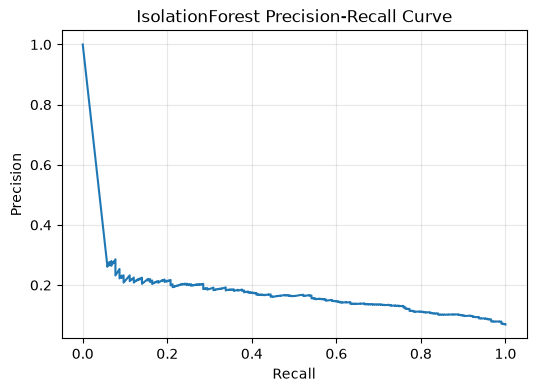

In [17]:
contamination = max(0.01, min(0.20, float(y_train.mean())))

iforest_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])


iforest_pipe.fit(X_train)

val_iforest_scores = -iforest_pipe.decision_function(X_val)
test_iforest_scores = -iforest_pipe.decision_function(X_test)


vmin, vmax = np.percentile(val_iforest_scores, [1, 99])
val_iforest_prob = np.clip((val_iforest_scores - vmin) / (vmax - vmin + 1e-9), 0, 1)
test_iforest_prob = np.clip((test_iforest_scores - vmin) / (vmax - vmin + 1e-9), 0, 1)

best_iforest = tune_threshold(y_val, val_iforest_prob, objective="f1")
iforest_metrics = evaluate_binary_scores(y_test, test_iforest_prob, best_iforest["threshold"], "IsolationForest baseline")
plot_pr_curve(y_test, test_iforest_prob, "IsolationForest Precision-Recall Curve")

In [20]:
if RUN_AUTOENCODER_BASELINE:
    normal_train_mask = y_train.values == 0
    pre_ae = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    X_train_scaled = pre_ae.fit_transform(X_train)
    X_val_scaled = pre_ae.transform(X_val)
    X_test_scaled = pre_ae.transform(X_test)

    ae = MLPRegressor(
        hidden_layer_sizes=(64, 16, 64),
        activation="relu",
        max_iter=100,
        early_stopping=True,
        random_state=RANDOM_STATE,
        verbose=False,
    )
    ae.fit(X_train_scaled[normal_train_mask], X_train_scaled[normal_train_mask])

    val_recon = ae.predict(X_val_scaled)
    test_recon = ae.predict(X_test_scaled)
    val_mse = ((X_val_scaled - val_recon) ** 2).mean(axis=1)
    test_mse = ((X_test_scaled - test_recon) ** 2).mean(axis=1)

    vmin, vmax = np.percentile(val_mse, [1, 99])
    val_ae_prob = np.clip((val_mse - vmin) / (vmax - vmin + 1e-9), 0, 1)
    test_ae_prob = np.clip((test_mse - vmin) / (vmax - vmin + 1e-9), 0, 1)

    best_ae = tune_threshold(y_val, val_ae_prob, objective="f1")
    ae_metrics = evaluate_binary_scores(y_test, test_ae_prob, best_ae["threshold"], "MLP Autoencoder-style baseline")
else:
    print("Skipped autoencoder-style baseline. Set RUN_AUTOENCODER_BASELINE=True to run.")


 MLP Autoencoder-style baseline
{
  "model": "MLP Autoencoder-style baseline",
  "threshold": 0.61,
  "precision": 0.5252918287937743,
  "recall": 0.6521739130434783,
  "f1": 0.5818965517241379,
  "accuracy": 0.9353548817060979,
  "roc_auc": 0.9381853454088991,
  "pr_auc": 0.5654854141054341
}
Confusion matrix:
[[2672  122]
 [  72  135]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      2794
           1       0.53      0.65      0.58       207

    accuracy                           0.94      3001
   macro avg       0.75      0.80      0.77      3001
weighted avg       0.94      0.94      0.94      3001




 XGBoost anomaly classifier
{
  "model": "XGBoost anomaly classifier",
  "threshold": 0.21000000000000002,
  "precision": 0.9257425742574258,
  "recall": 0.9033816425120773,
  "f1": 0.9144254278728606,
  "accuracy": 0.9883372209263579,
  "roc_auc": 0.9950739853170527,
  "pr_auc": 0.9633229140498862
}
Confusion matrix:
[[2779   15]
 [  20  187]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2794
           1       0.93      0.90      0.91       207

    accuracy                           0.99      3001
   macro avg       0.96      0.95      0.95      3001
weighted avg       0.99      0.99      0.99      3001



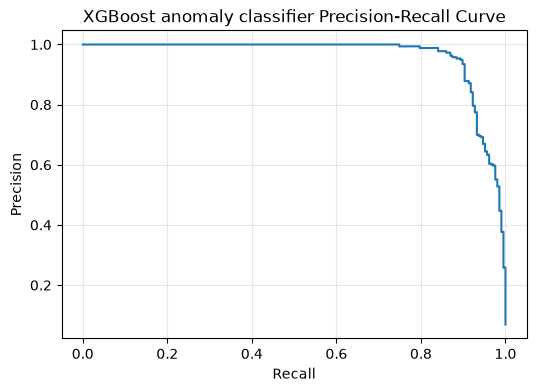

In [21]:
def make_supervised_anomaly_model():
    try:
        from xgboost import XGBClassifier
        pos = max(1, int(y_train.sum()))
        neg = max(1, int(len(y_train) - y_train.sum()))
        scale_pos_weight = neg / pos
        model = XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        name = "XGBoost anomaly classifier"
    except Exception:
        model = HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.04,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=RANDOM_STATE,
        )
        name = "HistGradientBoosting anomaly classifier"
    return name, Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model),
    ])

anom_model_name, anomaly_model = make_supervised_anomaly_model()
anomaly_model.fit(X_train, y_train)

if hasattr(anomaly_model.named_steps["model"], "predict_proba"):
    val_anom_prob = anomaly_model.predict_proba(X_val)[:, 1]
    test_anom_prob = anomaly_model.predict_proba(X_test)[:, 1]
else:
    val_raw = anomaly_model.decision_function(X_val)
    test_raw = anomaly_model.decision_function(X_test)
    val_anom_prob = 1 / (1 + np.exp(-val_raw))
    test_anom_prob = 1 / (1 + np.exp(-test_raw))

best_anom = tune_threshold(y_val, val_anom_prob, objective="f1")
anom_metrics = evaluate_binary_scores(y_test, test_anom_prob, best_anom["threshold"], anom_model_name)
plot_pr_curve(y_test, test_anom_prob, f"{anom_model_name} Precision-Recall Curve")

In [22]:
recall_target = 0.90
best_recall_threshold = tune_threshold(y_val, val_anom_prob, objective="precision", min_recall=recall_target)
print("Recall-biased threshold:", best_recall_threshold)
recall_biased_metrics = evaluate_binary_scores(
    y_test,
    test_anom_prob,
    best_recall_threshold["threshold"],
    f"{anom_model_name} recall-biased threshold"
)

Recall-biased threshold: {'threshold': 0.13, 'precision': 0.7671232876712328, 'recall': 0.9032258064516129, 'f1': 0.8296296296296296, 'score': 0.7671232876712328}

 XGBoost anomaly classifier recall-biased threshold
{
  "model": "XGBoost anomaly classifier recall-biased threshold",
  "threshold": 0.13,
  "precision": 0.8304347826086956,
  "recall": 0.9227053140096618,
  "f1": 0.8741418764302059,
  "accuracy": 0.9816727757414195,
  "roc_auc": 0.9950739853170527,
  "pr_auc": 0.9633229140498862
}
Confusion matrix:
[[2755   39]
 [  16  191]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2794
           1       0.83      0.92      0.87       207

    accuracy                           0.98      3001
   macro avg       0.91      0.95      0.93      3001
weighted avg       0.98      0.98      0.98      3001



In [23]:
Y_train_fault = feat_df.loc[train_idx, anomaly_cols].astype(int)
Y_val_fault = feat_df.loc[val_idx, anomaly_cols].astype(int)
Y_test_fault = feat_df.loc[test_idx, anomaly_cols].astype(int)

base_fault_model = ExtraTreesClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

fault_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", MultiOutputClassifier(base_fault_model, n_jobs=-1)),
])

fault_model.fit(X_train, Y_train_fault)


fault_prob_list = fault_model.named_steps["model"].predict_proba(
    fault_model.named_steps["imputer"].transform(X_test)
)

def probs_from_multioutput(prob_list):
    cols = []
    for p in prob_list:
        if p.shape[1] == 1:
            cols.append(np.zeros(p.shape[0]))
        else:
            cols.append(p[:, 1])
    return np.vstack(cols).T

fault_test_prob = probs_from_multioutput(fault_prob_list)
fault_test_pred = (fault_test_prob >= 0.50).astype(int)

print("Per-label fault diagnosis report:")
print(classification_report(Y_test_fault.values, fault_test_pred, target_names=anomaly_cols, zero_division=0))


test_true_top = Y_test_fault.values.argmax(axis=1)
test_pred_top = fault_test_prob.argmax(axis=1)
anom_rows_test = Y_test_fault.sum(axis=1).values > 0
if anom_rows_test.sum() > 0:
    top1_acc = accuracy_score(test_true_top[anom_rows_test], test_pred_top[anom_rows_test])
    print(f"Top-1 fault accuracy on anomalous test rows: {top1_acc:.4f}")
else:
    print("No anomalous rows in test split for top-1 evaluation.")

fault_prob_df = pd.DataFrame(fault_test_prob, columns=[f"prob_{c}" for c in anomaly_cols], index=test_idx)
display(fault_prob_df.head())

Per-label fault diagnosis report:
                    precision    recall  f1-score   support

 anomaly_reduction       1.00      0.88      0.94        52
anomaly_electric_1       0.00      0.00      0.00         3
 anomaly_bearing_1       0.00      0.00      0.00         3
anomaly_workroll_1       0.00      0.00      0.00         7
anomaly_electric_2       0.00      0.00      0.00         0
 anomaly_bearing_2       0.00      0.00      0.00         5
anomaly_workroll_2       0.00      0.00      0.00         0
anomaly_electric_3       1.00      0.12      0.22         8
 anomaly_bearing_3       0.00      0.00      0.00        17
anomaly_workroll_3       0.00      0.00      0.00        14
anomaly_electric_4       1.00      0.43      0.60        30
 anomaly_bearing_4       0.00      0.00      0.00         7
anomaly_workroll_4       0.00      0.00      0.00        14
anomaly_electric_5       0.00      0.00      0.00        27
 anomaly_bearing_5       0.00      0.00      0.00         5
anoma

,prob_anomaly_reduction,prob_anomaly_electric_1,prob_anomaly_bearing_1,prob_anomaly_workroll_1,prob_anomaly_electric_2,prob_anomaly_bearing_2,prob_anomaly_workroll_2,prob_anomaly_electric_3,prob_anomaly_bearing_3,prob_anomaly_workroll_3,prob_anomaly_electric_4,prob_anomaly_bearing_4,prob_anomaly_workroll_4,prob_anomaly_electric_5,prob_anomaly_bearing_5,prob_anomaly_workroll_5
17002,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0000,0.0,0.0,0.000000,0.000000,0.0,0.0
17003,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.002497,0.0,0.000000,0.0000,0.0,0.0,0.000000,0.000000,0.0,0.0
17004,0.007355,0.00249,0.0,0.0,0.002500,0.0,0.002495,0.0,0.000000,0.0000,0.0,0.0,0.000000,0.000000,0.0,0.0
17005,0.007441,0.00000,0.0,0.0,0.000000,0.0,0.004985,0.0,0.002498,0.0025,0.0,0.0,0.002493,0.002485,0.0,0.0
17006,0.000000,0.00000,0.0,0.0,0.004989,0.0,0.000000,0.0,0.000000,0.0025,0.0,0.0,0.002500,0.000000,0.0,0.0


In [24]:
y_rul_train = feat_df.loc[train_idx, "rul_urgency_id"].astype(int)
y_rul_val = feat_df.loc[val_idx, "rul_urgency_id"].astype(int)
y_rul_test = feat_df.loc[test_idx, "rul_urgency_id"].astype(int)

rul_band_names = {
    0: "monitor",
    1: "within_7_shifts",
    2: "within_3_shifts",
    3: "within_1_shift",
    4: "immediate",
}

rul_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rul_clf.fit(X_train, y_rul_train)
rul_test_pred = rul_clf.predict(X_test)
rul_test_prob = rul_clf.predict_proba(X_test)

print("Proxy RUL / urgency band classification report:")
print(classification_report(
    y_rul_test,
    rul_test_pred,
    labels=[0,1,2,3,4],
    target_names=[rul_band_names[i] for i in [0,1,2,3,4]],
    zero_division=0,
))
print("Confusion matrix:")
print(confusion_matrix(y_rul_test, rul_test_pred, labels=[0,1,2,3,4]))

Proxy RUL / urgency band classification report:
                 precision    recall  f1-score   support

        monitor       0.00      0.00      0.00         8
within_7_shifts       0.00      0.00      0.00         0
within_3_shifts       0.00      0.00      0.00         0
 within_1_shift       0.95      1.00      0.97      2786
      immediate       1.00      0.30      0.46       207

       accuracy                           0.95      3001
      macro avg       0.39      0.26      0.29      3001
   weighted avg       0.95      0.95      0.94      3001

Confusion matrix:
[[   0    0    0    8    0]
 [   0    0    0    0    0]
 [   0    0    0    0    0]
 [   0    0    0 2786    0]
 [   0    0    0  145   62]]


Proxy RUL regression MAE observations: 37.14
Proxy RUL regression RMSE observations: 108.46
Approx MAE shifts: 0.19


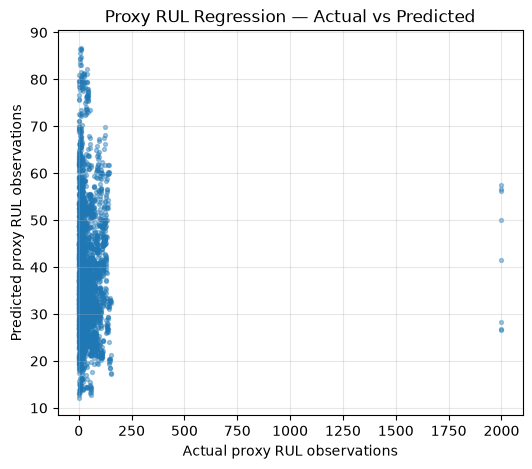

In [25]:
y_rul_obs_train = feat_df.loc[train_idx, "proxy_rul_obs"].astype(float)
y_rul_obs_test = feat_df.loc[test_idx, "proxy_rul_obs"].astype(float)

rul_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
rul_reg.fit(X_train, y_rul_obs_train)
rul_obs_pred = rul_reg.predict(X_test)

mae = mean_absolute_error(y_rul_obs_test, rul_obs_pred)
rmse = math.sqrt(mean_squared_error(y_rul_obs_test, rul_obs_pred))
print(f"Proxy RUL regression MAE observations: {mae:.2f}")
print(f"Proxy RUL regression RMSE observations: {rmse:.2f}")
print(f"Approx MAE shifts: {mae / OBS_PER_SHIFT:.2f}")

plt.figure(figsize=(6, 5))
plt.scatter(y_rul_obs_test, rul_obs_pred, s=8, alpha=0.4)
plt.xlabel("Actual proxy RUL observations")
plt.ylabel("Predicted proxy RUL observations")
plt.title("Proxy RUL Regression — Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
def infer_stand_from_fault_label(label: str):
    label = str(label).lower()
    m = re.search(r"_(\d)$", label)
    if m:
        return f"stand_{m.group(1)}"
    return "mill_level"


def risk_level_from_score(score):
    if score >= 76:
        return "critical"
    if score >= 56:
        return "high"
    if score >= 31:
        return "medium"
    return "low"


def get_top_faults(prob_row, top_k=3):
    pairs = list(zip(anomaly_cols, prob_row))
    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
    return pairs[:top_k]


def compute_row_trend_risk(row):
    z_cols = [c for c in feature_cols if c.endswith("z_recent_30")]
    if not z_cols:
        return 0.0
    vals = np.abs(row[z_cols].astype(float).values)
    # Convert z-score magnitude into 0-1 risk, robustly clipped.
    return float(np.clip(np.nanpercentile(vals, 90) / 5.0, 0, 1))

health_rows = []
for local_pos, idx in enumerate(test_idx):
    row = feat_df.loc[idx]
    anom_prob = float(test_anom_prob[local_pos])
    top_faults = get_top_faults(fault_test_prob[local_pos], top_k=3)
    top_fault, top_fault_conf = top_faults[0]
    pred_rul_id = int(rul_test_pred[local_pos])
    rul_severity = pred_rul_id / 4.0
    trend_risk = compute_row_trend_risk(row)
    equipment_criticality = 0.80  # default for TCM rolling stands; can be stand-specific later

    risk_score = 100 * (
        0.35 * anom_prob +
        0.25 * rul_severity +
        0.15 * float(top_fault_conf) +
        0.15 * trend_risk +
        0.10 * equipment_criticality
    )
    risk_score = float(np.clip(risk_score, 0, 100))
    health_index = float(np.clip(100 - risk_score, 0, 100))

    health_rows.append({
        "timestamp_index": int(row["timestamp_index"]),
        "predicted_is_anomaly": int(anom_prob >= best_anom["threshold"]),
        "anomaly_probability": anom_prob,
        "top_fault": top_fault,
        "top_fault_confidence": float(top_fault_conf),
        "abnormal_stand": infer_stand_from_fault_label(top_fault),
        "predicted_rul_band": rul_band_names[pred_rul_id],
        "proxy_rul_obs_pred": float(rul_obs_pred[local_pos]),
        "trend_risk": trend_risk,
        "risk_score": risk_score,
        "risk_level": risk_level_from_score(risk_score),
        "health_index": health_index,
        "true_is_anomaly": int(y_test.iloc[local_pos]),
        "true_dominant_fault": row["dominant_fault"],
        "true_rul_band": row["rul_urgency_band"],
    })

health_df = pd.DataFrame(health_rows)
display(health_df.head(10))
display(health_df["risk_level"].value_counts().to_frame("count"))

,timestamp_index,predicted_is_anomaly,anomaly_probability,top_fault,top_fault_confidence,abnormal_stand,predicted_rul_band,proxy_rul_obs_pred,trend_risk,risk_score,risk_level,health_index,true_is_anomaly,true_dominant_fault,true_rul_band
0,17002,0,0.011743,anomaly_reduction,0.000000,mill_level,within_1_shift,62.785413,0.216014,30.401214,low,69.598786,0,normal,within_1_shift
1,17003,0,0.024342,anomaly_workroll_2,0.002497,stand_2,within_1_shift,57.361449,0.204364,30.704888,low,69.295112,0,normal,within_1_shift
2,17004,0,0.031792,anomaly_reduction,0.007355,mill_level,within_1_shift,56.026816,0.251474,31.745164,medium,68.254836,0,normal,within_1_shift
3,17005,1,0.527535,anomaly_reduction,0.007441,mill_level,within_1_shift,57.698603,0.422736,51.666396,medium,48.333604,0,normal,within_1_shift
4,17006,0,0.017616,anomaly_electric_2,0.004989,stand_2,within_1_shift,62.761941,0.200548,30.449625,low,69.550375,0,normal,within_1_shift
5,17007,0,0.024827,anomaly_workroll_4,0.002500,stand_4,within_1_shift,63.559462,0.177927,30.325361,low,69.674639,0,normal,within_1_shift
6,17008,0,0.021714,anomaly_reduction,0.032238,mill_level,within_1_shift,63.749274,0.177310,30.653196,low,69.346804,0,normal,within_1_shift
7,17009,0,0.038123,anomaly_electric_2,0.002500,stand_2,within_1_shift,64.561675,0.179274,30.810928,low,69.189072,0,normal,within_1_shift
8,17010,0,0.016286,anomaly_electric_1,0.022464,stand_1,within_1_shift,63.727376,0.226665,31.056922,medium,68.943078,0,normal,within_1_shift
9,17011,1,0.999666,anomaly_reduction,0.879371,mill_level,immediate,61.939563,0.370219,86.732181,critical,13.267819,1,anomaly_reduction,immediate


,count
risk_level,
medium,2207
low,629
high,111
critical,54


In [27]:
latest_window = health_df.tail(500).copy()
priority = (
    latest_window
    .groupby("abnormal_stand", as_index=False)
    .agg(
        max_risk_score=("risk_score", "max"),
        mean_risk_score=("risk_score", "mean"),
        max_anomaly_probability=("anomaly_probability", "max"),
        latest_fault=("top_fault", lambda s: s.iloc[-1]),
        latest_rul_band=("predicted_rul_band", lambda s: s.iloc[-1]),
        latest_health_index=("health_index", lambda s: s.iloc[-1]),
        alert_count=("predicted_is_anomaly", "sum"),
    )
)
priority["risk_level"] = priority["max_risk_score"].apply(risk_level_from_score)
priority = priority.sort_values(["max_risk_score", "alert_count"], ascending=False).reset_index(drop=True)
priority.insert(0, "rank", np.arange(1, len(priority) + 1))

display(priority)

,rank,abnormal_stand,max_risk_score,mean_risk_score,max_anomaly_probability,latest_fault,latest_rul_band,latest_health_index,alert_count,risk_level
0,1,mill_level,90.048525,37.941231,0.999970,anomaly_reduction,within_1_shift,65.356589,9,critical
1,2,stand_5,75.157462,35.827641,0.967924,anomaly_workroll_5,within_1_shift,67.316562,6,high
2,3,stand_4,74.307044,36.503943,0.982271,anomaly_workroll_4,within_1_shift,67.290210,8,high
3,4,stand_3,74.121757,35.128309,0.969718,anomaly_bearing_3,within_1_shift,69.473420,8,high
4,5,stand_1,70.441979,33.399877,0.975511,anomaly_workroll_1,within_1_shift,68.019998,3,high
5,6,stand_2,35.879875,32.002951,0.060398,anomaly_bearing_2,within_1_shift,68.684773,0,medium


In [28]:
def evidence_for_index(idx: int, top_n: int = 8):
    row = feat_df.loc[idx]
    z_cols = [c for c in feature_cols if c.endswith("z_recent_30")]
    evidence = []
    for zc in z_cols:
        val = float(row.get(zc, 0))
        if np.isfinite(val):
            original_signal = zc.replace("_z_recent_30", "")
            evidence.append((original_signal, val, abs(val)))
    evidence = sorted(evidence, key=lambda x: x[2], reverse=True)[:top_n]
    return pd.DataFrame(evidence, columns=["signal", "z_recent_30", "abs_z"])


highest_risk_idx = int(health_df.sort_values("risk_score", ascending=False).iloc[0]["timestamp_index"])
print("Highest-risk timestamp_index:", highest_risk_idx)
display(health_df[health_df["timestamp_index"] == highest_risk_idx])
display(evidence_for_index(highest_risk_idx, top_n=10))

Highest-risk timestamp_index: 18792


,timestamp_index,predicted_is_anomaly,anomaly_probability,top_fault,top_fault_confidence,abnormal_stand,predicted_rul_band,proxy_rul_obs_pred,trend_risk,risk_score,risk_level,health_index,true_is_anomaly,true_dominant_fault,true_rul_band
1790,18792,1,0.999981,anomaly_reduction,0.994752,mill_level,immediate,61.72567,0.62035,92.225862,critical,7.774138,1,anomaly_reduction,immediate


,signal,z_recent_30,abs_z
0,torque_5,3.416189,3.416189
1,torque_3,3.212103,3.212103
2,torque_4,3.106190,3.106190
3,force_3,3.105607,3.105607
4,reduction_1,-3.097892,3.097892
5,force_5,2.947073,2.947073
6,force_4,2.744203,2.744203
7,gap_1,2.013841,2.013841
8,torque_2,1.898477,1.898477
9,force_2,1.739468,1.739468


,feature,importance
59,power_to_torque_ratio_2,0.024184
98,motor_power_diff_2_1,0.020467
99,motor_power_ratio_2_1,0.018700
80,speed_power_ratio_5,0.016345
68,speed_power_ratio_3,0.016031
74,speed_power_ratio_4,0.014369
91,force_ratio_2_1,0.013876
90,force_diff_2_1,0.012452
56,speed_power_ratio_1,0.012395
272,force_4_z_recent_60,0.011186


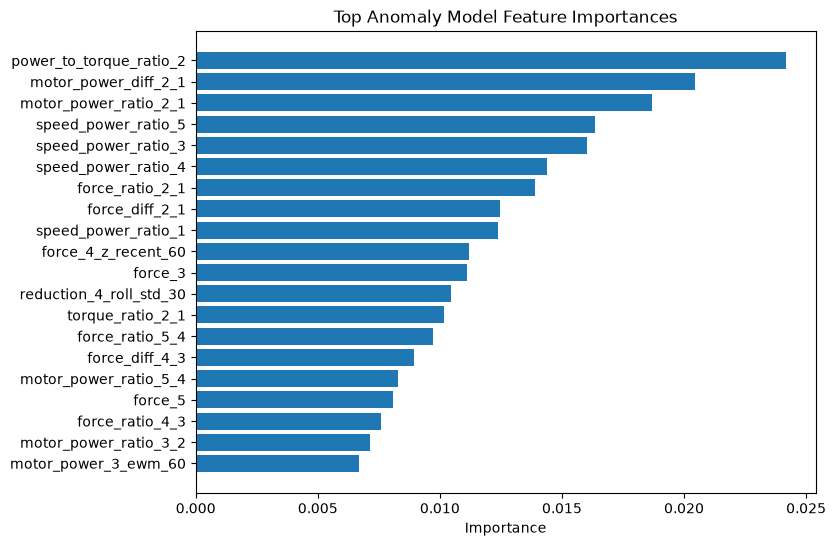

In [29]:

model_step = anomaly_model.named_steps["model"]
importance_df = None

if hasattr(model_step, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model_step.feature_importances_,
    }).sort_values("importance", ascending=False)
else:
    sample_n = min(1200, len(X_test))
    X_sample = X_test.iloc[:sample_n]
    y_sample = y_test.iloc[:sample_n]
    perm = permutation_importance(
        anomaly_model,
        X_sample,
        y_sample,
        scoring="f1",
        n_repeats=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": perm.importances_mean,
    }).sort_values("importance", ascending=False)

importance_df.to_csv(OUTPUT_DIR / "anomaly_feature_importance.csv", index=False)
display(importance_df.head(25))

plt.figure(figsize=(8, 6))
top_imp = importance_df.head(20).sort_values("importance", ascending=True)
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top Anomaly Model Feature Importances")
plt.xlabel("Importance")
plt.show()

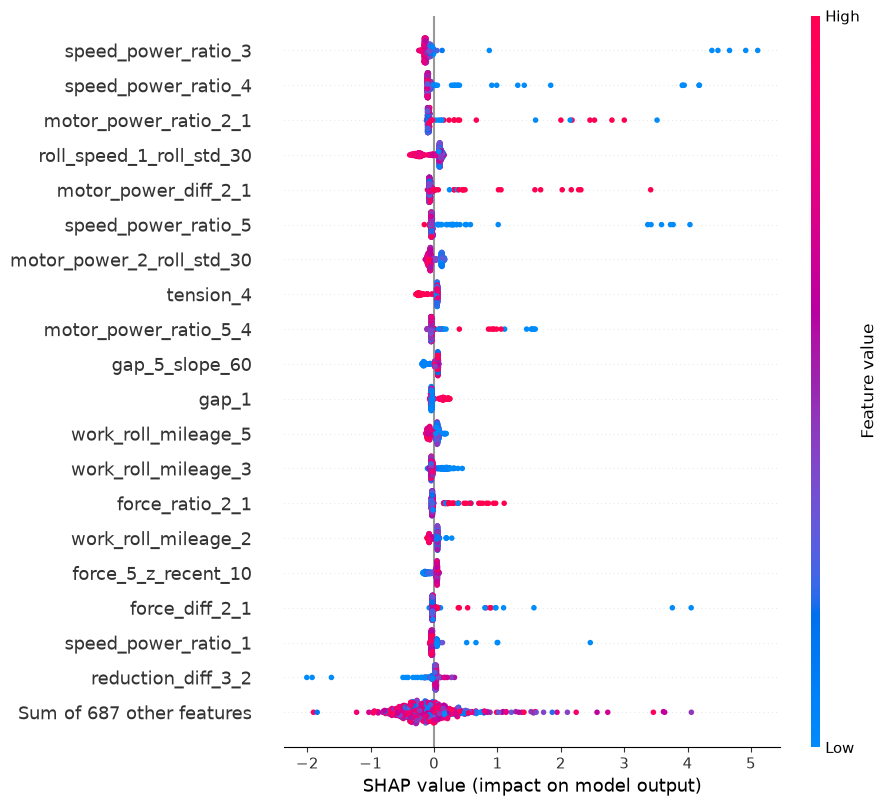

In [30]:
try:
    import shap
    X_test_imp = pd.DataFrame(
        anomaly_model.named_steps["imputer"].transform(X_test),
        columns=feature_cols,
        index=X_test.index,
    )
    tree_model = anomaly_model.named_steps["model"]
    if hasattr(tree_model, "predict_proba"):
        explainer = shap.Explainer(tree_model, X_test_imp.sample(min(500, len(X_test_imp)), random_state=RANDOM_STATE))
        shap_values = explainer(X_test_imp.sample(min(500, len(X_test_imp)), random_state=RANDOM_STATE))
        shap.plots.beeswarm(shap_values, max_display=20)
    else:
        print("SHAP skipped: model type not directly supported.")
except Exception as e:
    print("SHAP skipped:", repr(e))

,feature,psi_train_vs_drift,drift_level
255,force_3_ewm_60,12.432495,high
237,force_2_roll_mean_60,12.432495,high
234,force_2_ewm_30,12.432495,high
286,force_5_roll_std_60,12.432495,high
239,force_2_ewm_60,12.432495,high
221,force_1_roll_mean_60,12.432495,high
218,force_1_ewm_30,12.432495,high
223,force_1_ewm_60,12.432495,high
216,force_1_roll_mean_30,12.040845,high
254,force_3_roll_std_60,12.040845,high


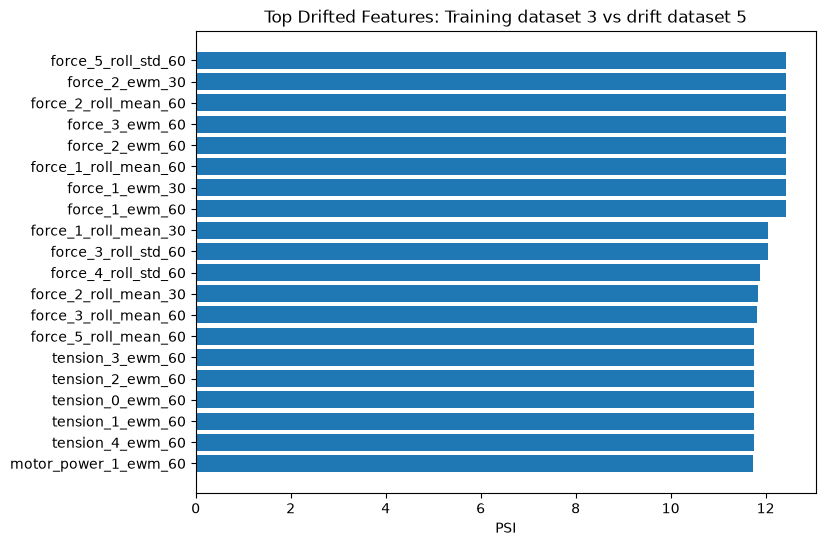

In [31]:
def calculate_psi(expected, actual, buckets=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()
    if expected.nunique() < 2 or actual.nunique() < 2:
        return 0.0

    quantiles = np.linspace(0, 1, buckets + 1)
    breaks = np.unique(np.quantile(expected, quantiles))
    if len(breaks) <= 2:
        return 0.0
    breaks[0] = -np.inf
    breaks[-1] = np.inf

    expected_counts = pd.cut(expected, breaks, include_lowest=True).value_counts(sort=False)
    actual_counts = pd.cut(actual, breaks, include_lowest=True).value_counts(sort=False)

    expected_pct = expected_counts / max(1, expected_counts.sum())
    actual_pct = actual_counts / max(1, actual_counts.sum())

    expected_pct = expected_pct.replace(0, 1e-6)
    actual_pct = actual_pct.replace(0, 1e-6)

    psi = ((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum()
    return float(psi)

X_drift = drift_feat_df[feature_cols].copy()

psi_rows = []
for c in feature_cols:
    psi_rows.append({
        "feature": c,
        "psi_train_vs_drift": calculate_psi(X_train[c], X_drift[c]),
    })
psi_df = pd.DataFrame(psi_rows).sort_values("psi_train_vs_drift", ascending=False)
psi_df["drift_level"] = pd.cut(
    psi_df["psi_train_vs_drift"],
    bins=[-np.inf, 0.1, 0.25, np.inf],
    labels=["low", "moderate", "high"],
)

display(psi_df.head(30))
psi_df.to_csv(OUTPUT_DIR / "drift_psi_train_vs_dataset5.csv", index=False)

plt.figure(figsize=(8, 6))
top_psi = psi_df.head(20).sort_values("psi_train_vs_drift", ascending=True)
plt.barh(top_psi["feature"], top_psi["psi_train_vs_drift"])
plt.title("Top Drifted Features: Training dataset 3 vs drift dataset 5")
plt.xlabel("PSI")
plt.show()

In [32]:

case_mask = feat_df.loc[train_idx, "is_anomaly"].values == 1
case_X = X_train.loc[case_mask]
case_meta = feat_df.loc[train_idx, ["timestamp_index", "dominant_fault", "active_faults", "rul_urgency_band"]].loc[case_X.index].copy()

case_pre = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
case_X_scaled = case_pre.fit_transform(case_X)

case_nn = NearestNeighbors(n_neighbors=min(5, len(case_X_scaled)), metric="cosine")
case_nn.fit(case_X_scaled)


def find_similar_cases(row_df: pd.DataFrame, top_k=5):
    row_scaled = case_pre.transform(row_df[feature_cols])
    dist, ind = case_nn.kneighbors(row_scaled, n_neighbors=min(top_k, len(case_meta)))
    rows = []
    for d, i in zip(dist[0], ind[0]):
        meta = case_meta.iloc[i].to_dict()
        meta["similarity"] = float(1 - d)
        rows.append(meta)
    return pd.DataFrame(rows)


similar_cases = find_similar_cases(feat_df.loc[[highest_risk_idx], feature_cols], top_k=5)
display(similar_cases)


case_memory_export = case_meta.copy()
case_memory_export["case_id"] = [f"CASE_{int(x):06d}" for x in case_memory_export["timestamp_index"]]
case_memory_export.to_csv(OUTPUT_DIR / "historical_case_memory.csv", index=False)
joblib.dump(case_pre, MODEL_DIR / "case_memory_preprocessor.joblib")
joblib.dump(case_nn, MODEL_DIR / "case_memory_nearest_neighbors.joblib")

,timestamp_index,dominant_fault,active_faults,rul_urgency_band,similarity
0,5173,anomaly_reduction,anomaly_reduction,immediate,0.784557
1,10969,anomaly_reduction,anomaly_reduction,immediate,0.751235
2,3237,anomaly_reduction,anomaly_reduction,immediate,0.738632
3,4056,anomaly_reduction,anomaly_reduction,immediate,0.730062
4,1672,anomaly_reduction,anomaly_reduction,immediate,0.725263


['tcm_modelling/models/case_memory_nearest_neighbors.joblib']

In [33]:
def predict_current_condition(row_index: int):
    row_X = feat_df.loc[[row_index], feature_cols]

    # Binary anomaly
    anom_prob = float(anomaly_model.predict_proba(row_X)[:, 1][0])
    is_alert = int(anom_prob >= best_anom["threshold"])

    # Fault probabilities
    prob_list = fault_model.named_steps["model"].predict_proba(
        fault_model.named_steps["imputer"].transform(row_X)
    )
    fp = probs_from_multioutput(prob_list)[0]
    top_faults = sorted(zip(anomaly_cols, fp), key=lambda x: x[1], reverse=True)[:3]
    top_fault, top_fault_conf = top_faults[0]

    # RUL urgency
    rul_id = int(rul_clf.predict(row_X)[0])
    rul_band = rul_band_names[rul_id]
    rul_obs = float(rul_reg.predict(row_X)[0])

    # Evidence
    ev_df = evidence_for_index(row_index, top_n=6)
    evidence = [
        f"{r.signal}: recent z-score {r.z_recent_30:.2f}"
        for r in ev_df.itertuples(index=False)
    ]

    trend_risk = compute_row_trend_risk(feat_df.loc[row_index])
    risk_score = float(np.clip(100 * (
        0.35 * anom_prob +
        0.25 * (rul_id / 4.0) +
        0.15 * float(top_fault_conf) +
        0.15 * trend_risk +
        0.10 * 0.80
    ), 0, 100))

    similar = find_similar_cases(row_X, top_k=3).to_dict(orient="records") if len(case_meta) else []

    return {
        "timestamp_index": int(feat_df.loc[row_index, "timestamp_index"]),
        "is_alert": bool(is_alert),
        "anomaly_probability": round(anom_prob, 4),
        "predicted_fault": top_fault,
        "predicted_stand": infer_stand_from_fault_label(top_fault),
        "fault_confidence": round(float(top_fault_conf), 4),
        "secondary_faults": [
            {"fault": f, "confidence": round(float(p), 4)}
            for f, p in top_faults[1:]
        ],
        "predicted_rul_band": rul_band,
        "proxy_rul_observations": round(rul_obs, 2),
        "proxy_rul_shifts": round(rul_obs / OBS_PER_SHIFT, 2),
        "health_index": round(100 - risk_score, 2),
        "risk_score": round(risk_score, 2),
        "risk_level": risk_level_from_score(risk_score),
        "evidence": evidence,
        "similar_historical_cases": similar,
        "disclaimer": "Proxy RUL is an urgency estimate derived from anomaly progression, not true run-to-failure life.",
    }

sample_result = predict_current_condition(highest_risk_idx)
print(json.dumps(sample_result, indent=2))

{
  "timestamp_index": 18792,
  "is_alert": true,
  "anomaly_probability": 1.0,
  "predicted_fault": "anomaly_reduction",
  "predicted_stand": "mill_level",
  "fault_confidence": 0.9948,
  "secondary_faults": [
    {
      "fault": "anomaly_workroll_3",
      "confidence": 0.0375
    },
    {
      "fault": "anomaly_bearing_3",
      "confidence": 0.03
    }
  ],
  "predicted_rul_band": "immediate",
  "proxy_rul_observations": 61.73,
  "proxy_rul_shifts": 0.31,
  "health_index": 7.77,
  "risk_score": 92.23,
  "risk_level": "critical",
  "evidence": [
    "torque_5: recent z-score 3.42",
    "torque_3: recent z-score 3.21",
    "torque_4: recent z-score 3.11",
    "force_3: recent z-score 3.11",
    "reduction_1: recent z-score -3.10",
    "force_5: recent z-score 2.95"
  ],
  "similar_historical_cases": [
    {
      "timestamp_index": 5173,
      "dominant_fault": "anomaly_reduction",
      "active_faults": "anomaly_reduction",
      "rul_urgency_band": "immediate",
      "similarity"

In [34]:
# Save model artifacts
joblib.dump(anomaly_model, MODEL_DIR / "anomaly_classifier.joblib")
joblib.dump(fault_model, MODEL_DIR / "fault_multilabel_classifier.joblib")
joblib.dump(rul_clf, MODEL_DIR / "rul_urgency_classifier.joblib")
joblib.dump(rul_reg, MODEL_DIR / "proxy_rul_regressor.joblib")


metadata = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "main_dataset_id": MAIN_DATASET_ID,
    "drift_dataset_id": DRIFT_DATASET_ID,
    "feature_count": len(feature_cols),
    "feature_cols": feature_cols,
    "anomaly_cols": anomaly_cols,
    "anomaly_threshold_f1": float(best_anom["threshold"]),
    "anomaly_threshold_recall_biased": float(best_recall_threshold["threshold"]),
    "obs_per_shift_assumption": OBS_PER_SHIFT,
    "rul_band_names": rul_band_names,
    "rul_disclaimer": "Proxy RUL/urgency is derived from distance to future anomaly windows. Dataset is not true run-to-failure.",
}
with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


health_df.to_csv(OUTPUT_DIR / "stand_health_predictions.csv", index=False)
priority.to_csv(OUTPUT_DIR / "maintenance_priority_board.csv", index=False)
fault_prob_df.to_csv(OUTPUT_DIR / "fault_probabilities_test.csv", index=True)
feat_df.to_parquet(PROCESSED_DIR / "tcm_features_dataset3.parquet", index=False)

metrics_summary = {
    "isolation_forest": iforest_metrics,
    "supervised_anomaly": anom_metrics,
    "recall_biased_anomaly": recall_biased_metrics,
    "proxy_rul_regression": {
        "mae_observations": float(mae),
        "rmse_observations": float(rmse),
        "mae_shifts": float(mae / OBS_PER_SHIFT),
    },
}
with open(OUTPUT_DIR / "metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved artifacts:")
for p in [MODEL_DIR, OUTPUT_DIR, PROCESSED_DIR]:
    print("\n", p)
    for file in sorted(p.glob("*")):
        print(" -", file.name)

Saved artifacts:

 tcm_modelling/models
 - anomaly_classifier.joblib
 - case_memory_nearest_neighbors.joblib
 - case_memory_preprocessor.joblib
 - fault_multilabel_classifier.joblib
 - model_metadata.json
 - proxy_rul_regressor.joblib
 - rul_urgency_classifier.joblib

 tcm_modelling/outputs
 - anomaly_feature_importance.csv
 - drift_psi_train_vs_dataset5.csv
 - fault_probabilities_test.csv
 - historical_case_memory.csv
 - maintenance_priority_board.csv
 - metrics_summary.json
 - stand_health_predictions.csv

 tcm_modelling/data/processed
 - tcm_features_dataset3.parquet
